<a href="https://colab.research.google.com/github/matijairv/challenge1-data-science-latam/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [38]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [52]:
# Calculo de ingresos por tienda

facturacion_tienda1 = tienda["Precio"].sum()
facturacion_tienda2 = tienda2["Precio"].sum()
facturacion_tienda3 = tienda3["Precio"].sum()
facturacion_tienda4 = tienda4["Precio"].sum()

print("Facturación Tienda 1: $", facturacion_tienda1)
print("Facturación Tienda 2: $", facturacion_tienda2)
print("Facturación Tienda 3: $", facturacion_tienda3)
print("Facturación Tienda 4: $", facturacion_tienda4)

Facturación Tienda 1: $ 1150880400.0
Facturación Tienda 2: $ 1116343500.0
Facturación Tienda 3: $ 1098019600.0
Facturación Tienda 4: $ 1038375700.0


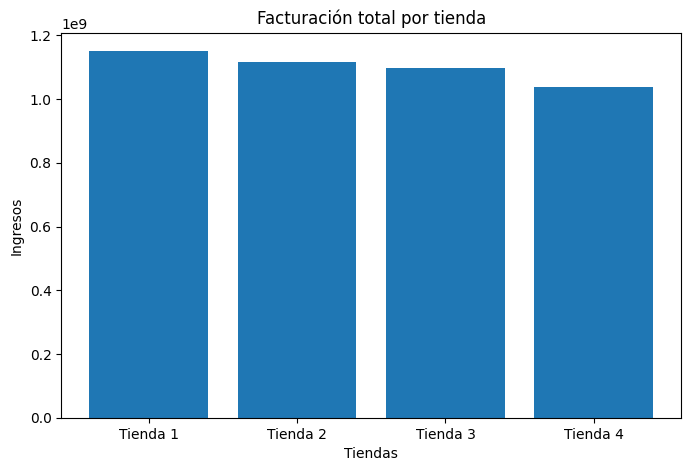

In [62]:
# Grafico
import matplotlib.pyplot as plt

facturacion = [
    facturacion_tienda1,
    facturacion_tienda2,
    facturacion_tienda3,
    facturacion_tienda4
]

tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

plt.figure(figsize=(8,5))
plt.bar(tiendas, facturacion)

plt.title("Facturación total por tienda")
plt.xlabel("Tiendas")
plt.ylabel("Ingresos")

plt.savefig("facturacion_tiendas.png", dpi=300)
plt.show()

# 2. Ventas por categoría

In [41]:
# Calculo de cantidad de productos vendidos por categoria en cada tienda
ventas_categoria1 = tienda["Categoría del Producto"].value_counts()
ventas_categoria2 = tienda2["Categoría del Producto"].value_counts()
ventas_categoria3 = tienda3["Categoría del Producto"].value_counts()
ventas_categoria4 = tienda4["Categoría del Producto"].value_counts()

print("Tienda 1")
print(ventas_categoria1)

print("\nTienda 2")
print(ventas_categoria2)

print("\nTienda 3")
print(ventas_categoria3)

print("\nTienda 4")
print(ventas_categoria4)

Tienda 1
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Tienda 2
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Tienda 3
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64

Tienda 4
Categoría del Producto
Muebles                    480
Electrónicos    

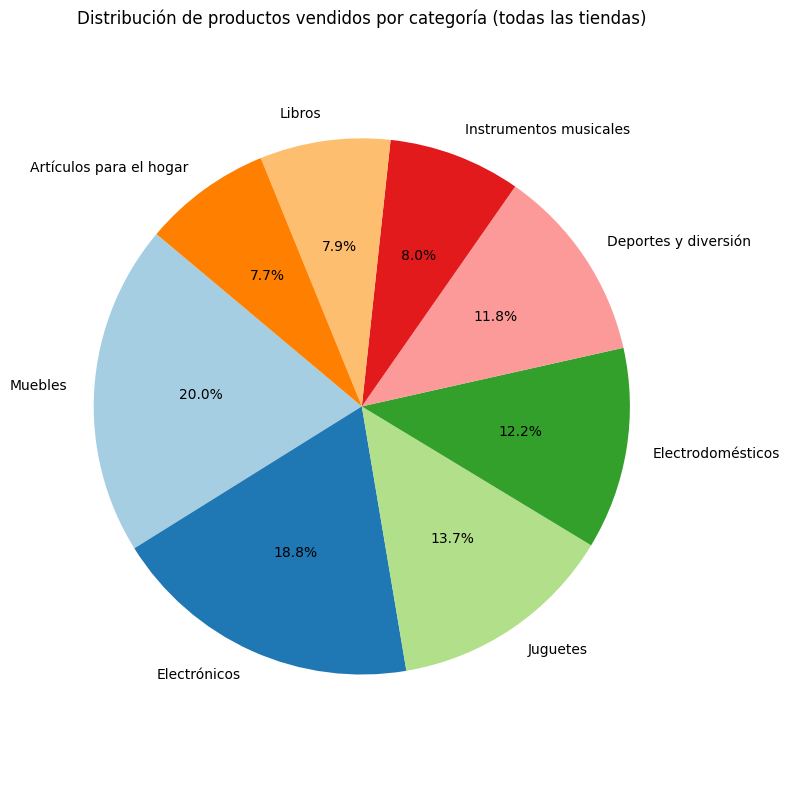

In [61]:
import matplotlib.pyplot as plt

# Grafico de distribucion de ventas por categoria de todas las tiendas

tiendas = pd.concat([tienda, tienda2, tienda3, tienda4])

# Contar productos vendidos por categoría
ventas_por_categoria = tiendas['Categoría del Producto'].value_counts()

# Crear gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(
    ventas_por_categoria.values,
    labels=ventas_por_categoria.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors  # Paleta de colores armónica
)
plt.title('Distribución de productos vendidos por categoría (todas las tiendas)')
plt.axis('equal')  # Asegura que el gráfico sea circular
plt.tight_layout()

plt.savefig("distribucion_categorias.png", dpi=300)
plt.show()


# 3. Calificación promedio de la tienda


Calificación promedio por tienda (de mejor a peor):
Tienda 3    4.048326
Tienda 2    4.037304
Tienda 4    3.995759
Tienda 1    3.976685
dtype: float64


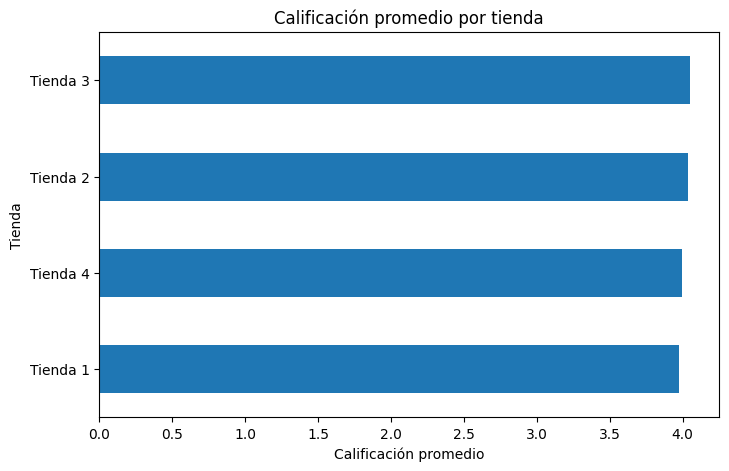

In [60]:
# Calcular calificación promedio por tienda
calificaciones = {
    "Tienda 1": tienda["Calificación"].mean(),
    "Tienda 2": tienda2["Calificación"].mean(),
    "Tienda 3": tienda3["Calificación"].mean(),
    "Tienda 4": tienda4["Calificación"].mean()
}

# Convertir a Serie de pandas
ratings = pd.Series(calificaciones)

# Ordenar de mayor a menor
ratings_ordenadas = ratings.sort_values(ascending=False)

# Mostrar resultados
print("Calificación promedio por tienda (de mejor a peor):")
print(ratings_ordenadas)

# Gráfico de barras horizontales
plt.figure(figsize=(8,5))
ratings_ordenadas.plot(kind="barh")

plt.title("Calificación promedio por tienda")
plt.xlabel("Calificación promedio")
plt.ylabel("Tienda")

# Invertir eje Y para que la mejor tienda quede arriba
plt.gca().invert_yaxis()

plt.savefig("promedios_calificaciones.png", dpi=300)
plt.show()

# 4. Productos más y menos vendidos

In [45]:

ventas_categoria_t1 = tienda['Categoría del Producto'].value_counts()
ventas_categoria_t2 = tienda2['Categoría del Producto'].value_counts()
ventas_categoria_t3 = tienda3['Categoría del Producto'].value_counts()
ventas_categoria_t4 = tienda4['Categoría del Producto'].value_counts()

# Mostrar resultados
print("Tienda 1 - Ventas por categoría:")
print(ventas_categoria_t1)

print("\nTienda 2 - Ventas por categoría:")
print(ventas_categoria_t2)

print("\nTienda 3 - Ventas por categoría:")
print(ventas_categoria_t3)

print("\nTienda 4 - Ventas por categoría:")
print(ventas_categoria_t4)

Tienda 1 - Ventas por categoría:
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Tienda 2 - Ventas por categoría:
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Tienda 3 - Ventas por categoría:
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64

Tienda 

# 5. Envío promedio por tienda

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

# Datos
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
precio_prom = [
    tienda['Precio'].mean(),
    tienda2['Precio'].mean(),
    tienda3['Precio'].mean(),
    tienda4['Precio'].mean()
]
envio_prom = [
    tienda['Costo de envío'].mean(),
    tienda2['Costo de envío'].mean(),
    tienda3['Costo de envío'].mean(),
    tienda4['Costo de envío'].mean()
]
#total_prom = [p + e for p, e in zip(precio_prom, envio_prom)]

# Posiciones para barras agrupadas
x = np.arange(len(tiendas))
width = 0.35

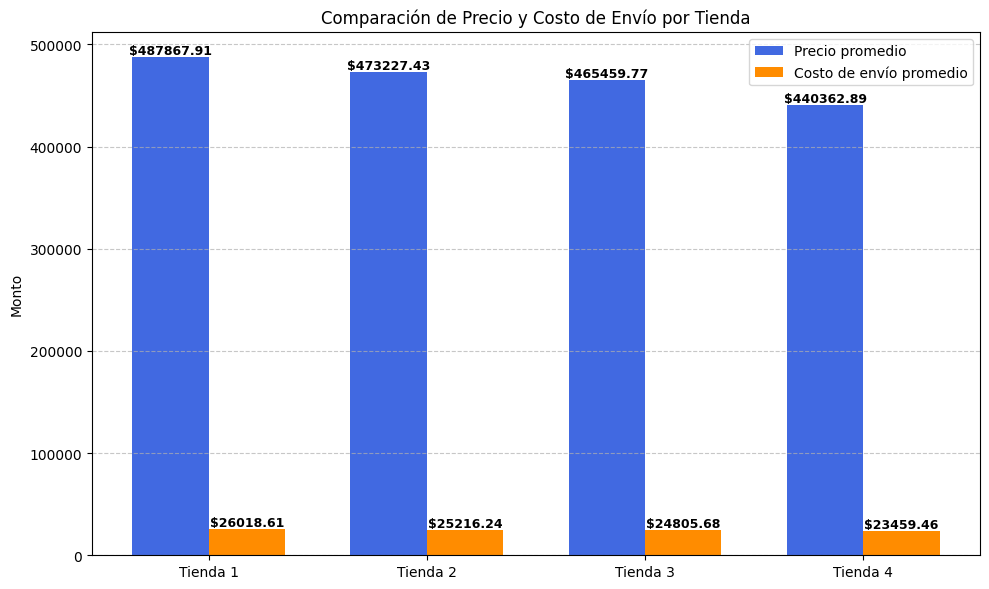

In [59]:
# Crear gráfico
plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, precio_prom, width, label='Precio promedio', color='royalblue')
bars2 = plt.bar(x + width/2, envio_prom, width, label='Costo de envío promedio', color='darkorange')

# Agregar valores encima de cada barra
for i in range(len(tiendas)):
    plt.text(x[i] - width/2, precio_prom[i] + 0.5, f"${precio_prom[i]:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(x[i] + width/2, envio_prom[i] + 0.5, f"${envio_prom[i]:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
   # plt.text(x[i], max(precio_prom[i], envio_prom[i]) + 5, f"Total: ${total_prom[i]:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Estética
plt.title('Comparación de Precio y Costo de Envío por Tienda')
plt.ylabel('Monto')
plt.xticks(x, tiendas)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("comparacion_precios_costos.png", dpi=300)
plt.show()

# 6. Conclusión y recomendación final
##🔍Introducción

El objetivo de este análisis fue evaluar el desempeño de las cuatro tiendas de la cadena Alura Store para determinar cuál de ellas debería vender el Sr. Juan con el fin de invertir en un nuevo emprendimiento. Para ello se analizaron distintos indicadores como la facturación total, las categorías de productos vendidas, las calificaciones de los clientes y los costos de envío.

##📊 Análisis de resultados

El análisis de facturación muestra que la **Tienda 4** presenta el menor ingreso total entre todas las tiendas, lo que indica un rendimiento económico inferior al resto.

En cuanto a las categorías de productos, todas las tiendas presentan distribuciones bastante similares, siendo Muebles y Electrónicos las categorías más vendidas en general. Esto sugiere que ninguna tienda tiene una ventaja clara en términos de variedad o especialización de productos.

Respecto a la calificación promedio de los clientes, la Tienda 3 y la Tienda 2 presentan las mejores valoraciones, mientras que la Tienda 4 se mantiene en una posición intermedia sin destacar significativamente.

Finalmente, el análisis del precio promedio de los productos y el costo de envío muestra que la Tienda 4 también presenta valores más bajos, lo que puede indicar menor valor promedio por transacción.

##✅ Conclusión

Considerando todos los factores analizados: facturación total, distribución de categorías de productos, calificaciones de clientes y costos asociados.
**Se recomienda que el Sr. Juan venda la Tienda 4.**

Esta tienda presenta el **menor rendimiento económico general y no muestra ventajas significativas frente a las demás tiendas**. Vender esta unidad permitiría concentrar recursos en las tiendas con mejor desempeño, optimizando así la eficiencia y rentabilidad del negocio.